<a href="https://colab.research.google.com/github/zavisk/AutonomousMedicalImage_TriageAgent/blob/main/chexpert_classification_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Autonomous Medical Image Triage Agent

**Multi-Label Chest X-Ray Classification using Deep Learning**

This notebook implements CNN-based pathology detection on the CheXpert dataset, comparing DenseNet-121 and EfficientNet-B0 architectures.

| | |
|---|---|
| **Authors** | Vishal Kumar, Deepashree Srinivasa Rao Rannore |
| **Course** | DS 5500 - Data Science Capstone |
| **Institution** | Northeastern University |
| **Dataset** | CheXpert (Stanford ML Group) |

## 1. Environment Setup

In [ ]:
!pip install -q torch torchvision pandas numpy matplotlib seaborn scikit-learn tqdm kaggle

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.metrics import roc_auc_score, roc_curve
from tqdm import tqdm
import json
import os
import warnings

warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

Using device: cuda


## 2. Configuration

In [ ]:
CONFIG = {
    'data_dir': '/content/chexpert/',
    'train_csv': '/content/chexpert/train.csv',
    'valid_csv': '/content/chexpert/valid.csv',
    'output_dir': '/content/outputs/',
    'sample_size': 50000,
    'train_split': 0.8,
    'image_size': 224,
    'batch_size': 64,
    'num_epochs': 15,
    'learning_rate': 1e-4,
    'num_workers': 2,
    'target_labels': ['Cardiomegaly', 'Pneumonia', 'Pneumothorax', 'Edema', 'Pleural Effusion'],
}

os.makedirs(CONFIG['output_dir'], exist_ok=True)

## 3. Dataset Download

Download CheXpert dataset from Kaggle. You need to:
1. Go to https://www.kaggle.com/settings
2. Click "Create New Token" under API section
3. Copy your username and key below

In [ ]:
# Setup Kaggle credentials
!mkdir -p ~/.kaggle

kaggle_credentials = {
    "username": "vishalkumar115",  # Replace with your username
    "key": "29cd5b1647505861cd0ea6b50c4b8407"          # Replace with your API key
}

with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_credentials, f)

!chmod 600 /root/.kaggle/kaggle.json

In [ ]:
# Download and extract CheXpert dataset
!kaggle datasets download -d ashery/chexpert -p /content/
!unzip -q /content/chexpert.zip -d /content/chexpert

Dataset URL: https://www.kaggle.com/datasets/ashery/chexpert
License(s): CC0-1.0
chexpert.zip: Skipping, found more recently modified local copy (use --force to force download)
replace /content/chexpert/train.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


In [ ]:
# Verify download
!ls -la /content/chexpert/

total 25892
drwxr-xr-x     4 root root     4096 Feb 23 23:24 .
drwxr-xr-x     1 root root     4096 Feb 23 22:48 ..
drwxr-xr-x 64542 root root  1953792 Feb 23 22:50 train
-rw-r--r--     1 root root 24505945 Apr 28  2021 train.csv
drwxr-xr-x   202 root root     4096 Feb 23 22:50 valid
-rw-r--r--     1 root root    32896 Apr 28  2021 valid.csv


## 4. Data Loading

In [ ]:
train_df = pd.read_csv(CONFIG['train_csv'])
valid_df = pd.read_csv(CONFIG['valid_csv'])

print(f"Training samples: {len(train_df):,}")
print(f"Validation samples: {len(valid_df):,}")
print(f"\nColumns: {train_df.columns.tolist()}")

Training samples: 223,414
Validation samples: 234

Columns: ['Path', 'Sex', 'Age', 'Frontal/Lateral', 'AP/PA', 'No Finding', 'Enlarged Cardiomediastinum', 'Cardiomegaly', 'Lung Opacity', 'Lung Lesion', 'Edema', 'Consolidation', 'Pneumonia', 'Atelectasis', 'Pneumothorax', 'Pleural Effusion', 'Pleural Other', 'Fracture', 'Support Devices']


## 5. Exploratory Data Analysis

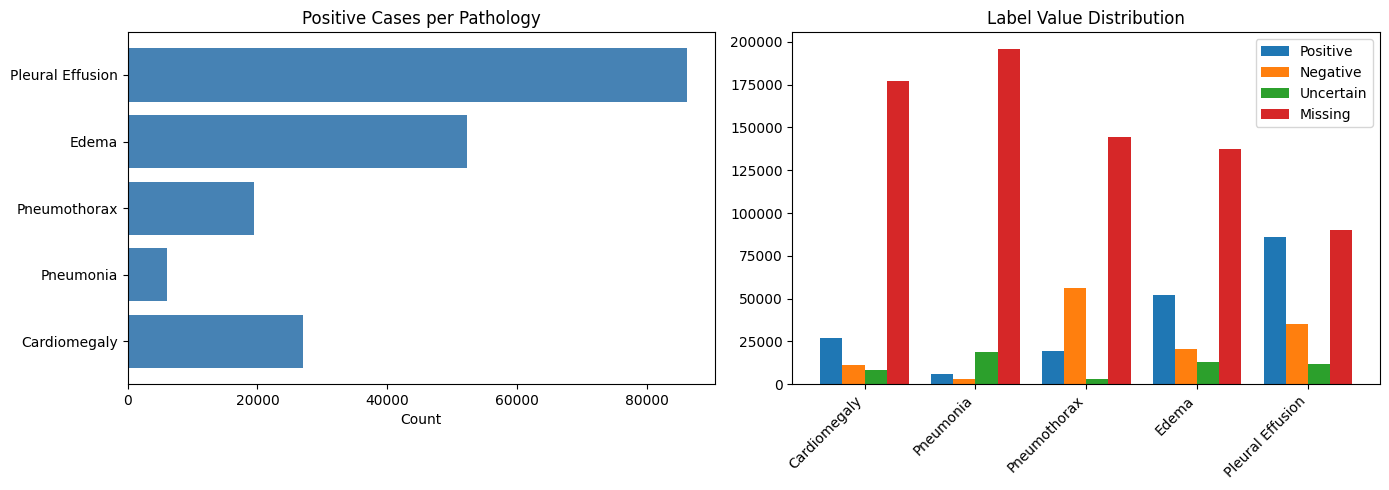

In [ ]:
def plot_label_distribution(df, labels):
    """Visualize pathology label distribution."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Positive cases count
    positive_counts = [(df[label] == 1.0).sum() for label in labels]
    axes[0].barh(labels, positive_counts, color='steelblue')
    axes[0].set_xlabel('Count')
    axes[0].set_title('Positive Cases per Pathology')

    # Label value distribution
    value_counts = []
    for label in labels:
        counts = {
            'Positive': (df[label] == 1.0).sum(),
            'Negative': (df[label] == 0.0).sum(),
            'Uncertain': (df[label] == -1.0).sum(),
            'Missing': df[label].isna().sum()
        }
        value_counts.append(counts)

    dist_df = pd.DataFrame(value_counts, index=labels)
    dist_df.plot(kind='bar', ax=axes[1], width=0.8)
    axes[1].set_title('Label Value Distribution')
    axes[1].set_xticklabels(labels, rotation=45, ha='right')

    plt.tight_layout()
    plt.savefig(f"{CONFIG['output_dir']}label_distribution.png", dpi=150)
    plt.show()

plot_label_distribution(train_df, CONFIG['target_labels'])

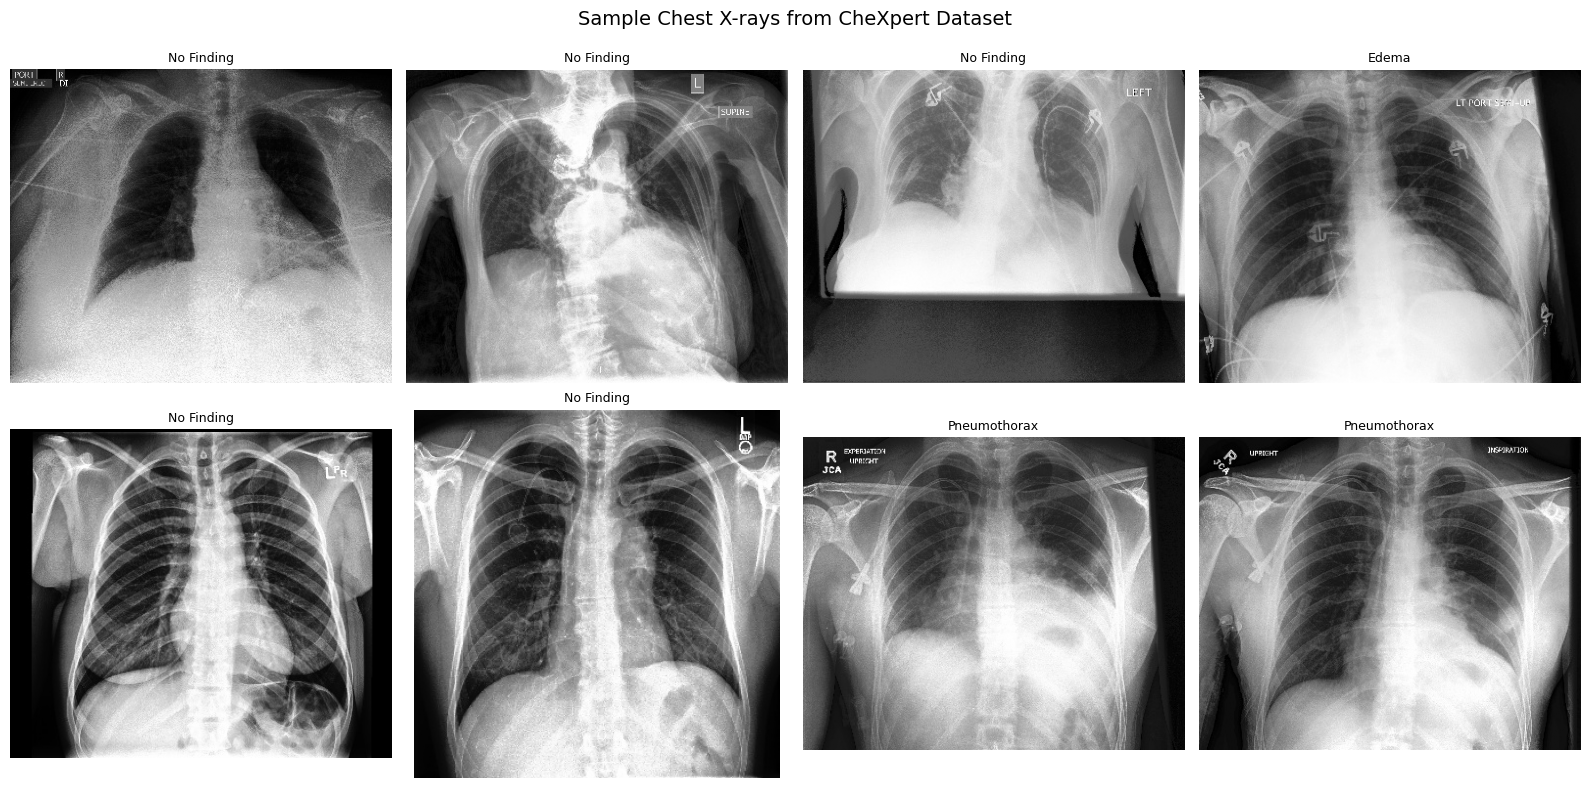

In [ ]:
def display_sample_images(df, data_dir, n_samples=8):
    """Display sample chest X-ray images with labels."""
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))

    for i, ax in enumerate(axes.flat):
        if i >= len(df):
            break
        img_path = data_dir + 'train/' + df.iloc[i]['Path'].split('train/')[-1]
        img = Image.open(img_path)
        ax.imshow(img, cmap='gray')
        ax.axis('off')

        pos_labels = [l for l in CONFIG['target_labels'] if df.iloc[i][l] == 1.0]
        title = ', '.join(pos_labels) if pos_labels else 'No Finding'
        ax.set_title(title[:35], fontsize=9)

    plt.suptitle('Sample Chest X-rays from CheXpert Dataset', fontsize=14)
    plt.tight_layout()
    plt.savefig(f"{CONFIG['output_dir']}sample_images.png", dpi=150)
    plt.show()

frontal_df = train_df[train_df['Frontal/Lateral'] == 'Frontal'].copy()
display_sample_images(frontal_df, CONFIG['data_dir'])

## 6. Data Preprocessing

In [ ]:
# Filter frontal view images and sample subset
frontal_df = train_df[train_df['Frontal/Lateral'] == 'Frontal'].copy()
frontal_df = frontal_df.head(CONFIG['sample_size']).reset_index(drop=True)

print(f"Using {len(frontal_df):,} frontal-view images for training")

Using 50,000 frontal-view images for training


In [ ]:
class CheXpertDataset(Dataset):
    """
    PyTorch Dataset for CheXpert images.
    Implements U-Ones policy: uncertain labels (-1) treated as positive.
    """

    def __init__(self, dataframe, root_dir, transform=None, labels=None):
        self.df = dataframe.reset_index(drop=True)
        self.root_dir = root_dir
        self.transform = transform
        self.labels = labels or CONFIG['target_labels']

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.root_dir + 'train/' + self.df.iloc[idx]['Path'].split('train/')[-1]
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        # U-Ones: treat uncertain (-1) as positive (1)
        label_values = []
        for col in self.labels:
            val = self.df.iloc[idx][col]
            label_values.append(1.0 if val == 1.0 or val == -1.0 else 0.0)

        return image, torch.tensor(label_values, dtype=torch.float32)

In [ ]:
# Data augmentation for training
train_transforms = transforms.Compose([
    transforms.Resize((CONFIG['image_size'], CONFIG['image_size'])),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# No augmentation for validation
val_transforms = transforms.Compose([
    transforms.Resize((CONFIG['image_size'], CONFIG['image_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
# Split into train/val sets
train_size = int(CONFIG['train_split'] * len(frontal_df))
train_df_split = frontal_df.iloc[:train_size]
val_df_split = frontal_df.iloc[train_size:]

# Create datasets
train_dataset = CheXpertDataset(train_df_split, CONFIG['data_dir'], transform=train_transforms)
val_dataset = CheXpertDataset(val_df_split, CONFIG['data_dir'], transform=val_transforms)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True, num_workers=CONFIG['num_workers'])
val_loader = DataLoader(val_dataset, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=CONFIG['num_workers'])

print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

Training batches: 625
Validation batches: 157


## 7. Model Architecture

In [ ]:
class DenseNet121(nn.Module):
    """DenseNet-121 with custom head for multi-label classification."""

    def __init__(self, num_classes=5):
        super(DenseNet121, self).__init__()
        self.model = models.densenet121(weights='IMAGENET1K_V1')
        in_features = self.model.classifier.in_features
        self.model.classifier = nn.Sequential(
            nn.Dropout(p=0.2),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.model(x)


class EfficientNetB0(nn.Module):
    """EfficientNet-B0 with custom head for multi-label classification."""

    def __init__(self, num_classes=5):
        super(EfficientNetB0, self).__init__()
        self.model = models.efficientnet_b0(weights='IMAGENET1K_V1')
        in_features = self.model.classifier[1].in_features
        self.model.classifier = nn.Sequential(
            nn.Dropout(p=0.2),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.model(x)

## 8. Training Pipeline

In [ ]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    """Train for one epoch and return average loss."""
    model.train()
    running_loss = 0.0

    for images, labels in tqdm(dataloader, desc="Training", leave=False):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(dataloader)


def evaluate(model, dataloader, criterion, device, labels):
    """Evaluate model and return loss, mean AUC, and per-class AUC."""
    model.eval()
    running_loss = 0.0
    all_preds, all_targets = [], []

    with torch.no_grad():
        for images, targets in tqdm(dataloader, desc="Evaluating", leave=False):
            images, targets = images.to(device), targets.to(device)
            outputs = model(images)
            loss = criterion(outputs, targets)

            running_loss += loss.item()
            all_preds.append(torch.sigmoid(outputs).cpu().numpy())
            all_targets.append(targets.cpu().numpy())

    all_preds = np.vstack(all_preds)
    all_targets = np.vstack(all_targets)

    # Calculate AUC for each pathology
    auc_scores = {}
    for i, label in enumerate(labels):
        try:
            auc_scores[label] = roc_auc_score(all_targets[:, i], all_preds[:, i])
        except ValueError:
            auc_scores[label] = 0.5

    return running_loss / len(dataloader), np.mean(list(auc_scores.values())), auc_scores

In [ ]:
def train_model(model, train_loader, val_loader, config, model_name):
    """Complete training loop with checkpointing."""
    model = model.to(DEVICE)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=config['learning_rate'])

    history = {'train_loss': [], 'val_loss': [], 'val_auc': [], 'per_class_auc': []}
    best_auc = 0.0

    print(f"\nTraining {model_name}")
    print("-" * 50)

    for epoch in range(config['num_epochs']):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
        val_loss, mean_auc, auc_scores = evaluate(model, val_loader, criterion, DEVICE, config['target_labels'])

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_auc'].append(mean_auc)
        history['per_class_auc'].append(auc_scores)

        # Save best model
        if mean_auc > best_auc:
            best_auc = mean_auc
            torch.save(model.state_dict(), f"{config['output_dir']}{model_name}_best.pth")

        print(f"Epoch {epoch+1}/{config['num_epochs']} | "
              f"Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"Val AUC: {mean_auc:.4f}")

    history['best_auc'] = best_auc
    print(f"Best Validation AUC: {best_auc:.4f}")

    return history

## 9. Model Training

In [ ]:
# Train DenseNet-121
densenet_model = DenseNet121(num_classes=len(CONFIG['target_labels']))
densenet_history = train_model(densenet_model, train_loader, val_loader, CONFIG, 'densenet121')


Training densenet121
--------------------------------------------------


Epoch 1/15 | Train Loss: 0.4063 | Val Loss: 0.3885 | Val AUC: 0.7958


Epoch 2/15 | Train Loss: 0.3663 | Val Loss: 0.3722 | Val AUC: 0.8110


Epoch 3/15 | Train Loss: 0.3551 | Val Loss: 0.3661 | Val AUC: 0.8165


Epoch 4/15 | Train Loss: 0.3455 | Val Loss: 0.3687 | Val AUC: 0.8151


...

Epoch 11/15 | Train Loss: 0.2643 | Val Loss: 0.4258 | Val AUC: 0.7943


Epoch 12/15 | Train Loss: 0.2478 | Val Loss: 0.4234 | Val AUC: 0.7935


Epoch 13/15 | Train Loss: 0.2311 | Val Loss: 0.4659 | Val AUC: 0.7801


Epoch 14/15 | Train Loss: 0.2147 | Val Loss: 0.4716 | Val AUC: 0.7793


Epoch 15/15 | Train Loss: 0.1986 | Val Loss: 0.4944 | Val AUC: 0.7800
Best Validation AUC: 0.8165


In [ ]:
# Train EfficientNet-B0
efficientnet_model = EfficientNetB0(num_classes=len(CONFIG['target_labels']))
efficientnet_history = train_model(efficientnet_model, train_loader, val_loader, CONFIG, 'efficientnet_b0')


Training efficientnet_b0
--------------------------------------------------


Epoch 1/15 | Train Loss: 0.4260 | Val Loss: 0.3875 | Val AUC: 0.7828


Epoch 2/15 | Train Loss: 0.3753 | Val Loss: 0.3764 | Val AUC: 0.8015


Epoch 3/15 | Train Loss: 0.3600 | Val Loss: 0.3708 | Val AUC: 0.8100


Epoch 4/15 | Train Loss: 0.3496 | Val Loss: 0.3677 | Val AUC: 0.8127


...

Epoch 11/15 | Train Loss: 0.2704 | Val Loss: 0.4138 | Val AUC: 0.7930


Epoch 12/15 | Train Loss: 0.2575 | Val Loss: 0.4328 | Val AUC: 0.7929


Epoch 13/15 | Train Loss: 0.2457 | Val Loss: 0.4421 | Val AUC: 0.7880


Epoch 14/15 | Train Loss: 0.2313 | Val Loss: 0.4628 | Val AUC: 0.7851


Epoch 15/15 | Train Loss: 0.2184 | Val Loss: 0.4755 | Val AUC: 0.7781
Best Validation AUC: 0.8127


## 10. Results Visualization

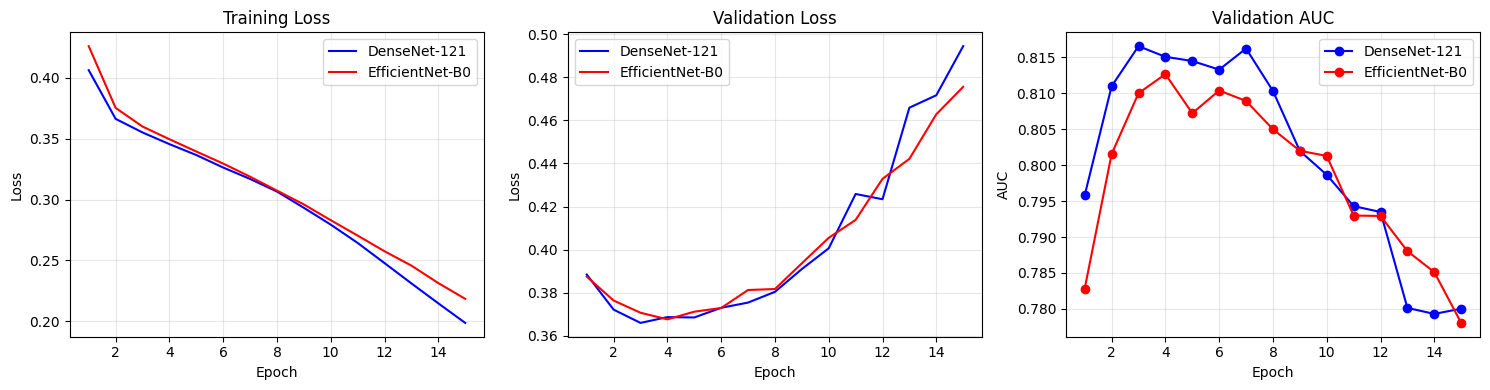

In [ ]:
def plot_training_curves(hist1, hist2, name1, name2):
    """Plot training curves for model comparison."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    epochs = range(1, len(hist1['train_loss']) + 1)

    # Training Loss
    axes[0].plot(epochs, hist1['train_loss'], 'b-', label=name1)
    axes[0].plot(epochs, hist2['train_loss'], 'r-', label=name2)
    axes[0].set_title('Training Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Validation Loss
    axes[1].plot(epochs, hist1['val_loss'], 'b-', label=name1)
    axes[1].plot(epochs, hist2['val_loss'], 'r-', label=name2)
    axes[1].set_title('Validation Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # Validation AUC
    axes[2].plot(epochs, hist1['val_auc'], 'b-o', label=name1)
    axes[2].plot(epochs, hist2['val_auc'], 'r-o', label=name2)
    axes[2].set_title('Validation AUC')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('AUC')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{CONFIG['output_dir']}training_curves.png", dpi=150)
    plt.show()

plot_training_curves(densenet_history, efficientnet_history, 'DenseNet-121', 'EfficientNet-B0')

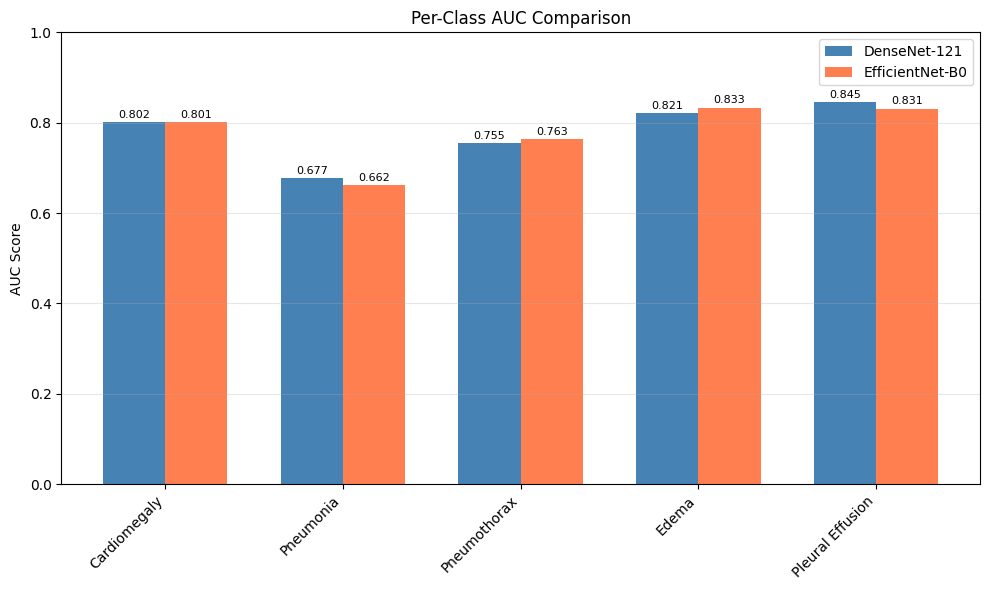

In [ ]:
def plot_per_class_auc(hist1, hist2, name1, name2, labels):
    """Create per-pathology AUC comparison chart."""
    fig, ax = plt.subplots(figsize=(10, 6))

    x = np.arange(len(labels))
    width = 0.35

    auc1 = [hist1['per_class_auc'][-1][l] for l in labels]
    auc2 = [hist2['per_class_auc'][-1][l] for l in labels]

    bars1 = ax.bar(x - width/2, auc1, width, label=name1, color='steelblue')
    bars2 = ax.bar(x + width/2, auc2, width, label=name2, color='coral')

    ax.set_ylabel('AUC Score')
    ax.set_title('Per-Class AUC Comparison')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.legend()
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3, axis='y')

    # Add value labels
    for bar in bars1 + bars2:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', fontsize=8)

    plt.tight_layout()
    plt.savefig(f"{CONFIG['output_dir']}per_class_auc.png", dpi=150)
    plt.show()

plot_per_class_auc(densenet_history, efficientnet_history, 'DenseNet-121', 'EfficientNet-B0', CONFIG['target_labels'])

## 11. Model Comparison

In [ ]:
def generate_comparison_report(hist1, hist2, name1, name2, labels):
    """Generate model comparison summary table."""
    data = {'Model': [name1, name2], 'Best AUC': [hist1['best_auc'], hist2['best_auc']]}

    for label in labels:
        data[label] = [hist1['per_class_auc'][-1][label], hist2['per_class_auc'][-1][label]]

    comparison_df = pd.DataFrame(data)
    comparison_df.to_csv(f"{CONFIG['output_dir']}model_comparison.csv", index=False)

    return comparison_df

comparison_df = generate_comparison_report(
    densenet_history, efficientnet_history,
    'DenseNet-121', 'EfficientNet-B0',
    CONFIG['target_labels']
)

print("Model Comparison Results")
print("=" * 60)
print(comparison_df.to_string(index=False))
print("=" * 60)

winner = comparison_df.loc[comparison_df['Best AUC'].idxmax(), 'Model']
print(f"\nBest Performing Model: {winner}")

Model Comparison Results
          Model  Best AUC  Cardiomegaly  Pneumonia  Pneumothorax    Edema  Pleural Effusion
   DenseNet-121  0.816543      0.801875   0.676802      0.755273 0.821070          0.845099
EfficientNet-B0  0.812653      0.800506   0.661822      0.763234 0.833315          0.831401

Best Performing Model: DenseNet-121


## 12. Inference

In [ ]:
def predict(image_path, model, transform, labels, device, threshold=0.5):
    """Run inference on a single chest X-ray image."""
    model.eval()

    image = Image.open(image_path).convert('RGB')
    image_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = torch.sigmoid(model(image_tensor))

    probs = outputs.cpu().numpy()[0]

    print("Prediction Results")
    print("-" * 40)

    for label, prob in zip(labels, probs):
        status = "POSITIVE" if prob >= threshold else "Negative"
        indicator = "⚠️" if prob >= threshold else "✓"
        print(f"{indicator} {label}: {prob:.1%} ({status})")

    return probs

In [ ]:
# Load best model and test on positive case
best_model = DenseNet121(num_classes=len(CONFIG['target_labels']))
best_model.load_state_dict(torch.load(f"{CONFIG['output_dir']}densenet121_best.pth"))
best_model = best_model.to(DEVICE)

# Find a Pneumothorax positive case
positive_case = frontal_df[frontal_df['Pneumothorax'] == 1.0].iloc[0]
test_path = CONFIG['data_dir'] + 'train/' + positive_case['Path'].split('train/')[-1]

print(f"Testing on Pneumothorax positive case...\n")
_ = predict(test_path, best_model, val_transforms, CONFIG['target_labels'], DEVICE)

Testing on Pneumothorax positive case...

Prediction Results
----------------------------------------
✓ Cardiomegaly: 3.7% (Negative)
✓ Pneumonia: 7.2% (Negative)
✓ Pneumothorax: 29.8% (Negative)
✓ Edema: 6.9% (Negative)
⚠️ Pleural Effusion: 51.9% (POSITIVE)


## 13. Save Outputs

In [ ]:
# Save configuration
with open(f"{CONFIG['output_dir']}config.json", 'w') as f:
    json.dump(CONFIG, f, indent=2)

# Save training history
history_data = {
    'densenet121': {
        'train_loss': densenet_history['train_loss'],
        'val_loss': densenet_history['val_loss'],
        'val_auc': densenet_history['val_auc'],
        'best_auc': densenet_history['best_auc']
    },
    'efficientnet_b0': {
        'train_loss': efficientnet_history['train_loss'],
        'val_loss': efficientnet_history['val_loss'],
        'val_auc': efficientnet_history['val_auc'],
        'best_auc': efficientnet_history['best_auc']
    }
}

with open(f"{CONFIG['output_dir']}training_history.json", 'w') as f:
    json.dump(history_data, f, indent=2)

print("All outputs saved.")
print(f"\nOutput files:")
!ls -la {CONFIG['output_dir']}

All outputs saved.

Output files:
total 45984
drwxr-xr-x 2 root root     4096 Feb 24 00:36 .
drwxr-xr-x 1 root root     4096 Feb 23 22:48 ..
-rw-r--r-- 1 root root      440 Feb 24 00:36 config.json
-rw-r--r-- 1 root root 28454614 Feb 23 23:33 densenet121_best.pth
-rw-r--r-- 1 root root 16363205 Feb 24 00:11 efficientnet_b0_best.pth
-rw-r--r-- 1 root root    91047 Feb 23 23:26 label_distribution.png
-rw-r--r-- 1 root root      330 Feb 24 00:35 model_comparison.csv
-rw-r--r-- 1 root root    69754 Feb 24 00:35 per_class_auc.png
-rw-r--r-- 1 root root  1951579 Feb 23 23:26 sample_images.png
-rw-r--r-- 1 root root   123091 Feb 24 00:35 training_curves.png
-rw-r--r-- 1 root root     2630 Feb 24 00:36 training_history.json
